<a href="https://colab.research.google.com/github/chiquixs/jobsheet/blob/main/data-mining/jobsheet7/StockExchange_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving prices-split-adjusted.csv to prices-split-adjusted.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
Intercept: 0.0022015933908647867
Slope: [-5.56344962e-01  7.56231017e-01  8.00069576e-01 -1.73091097e-10]
RMSE: 0.5902034552632122


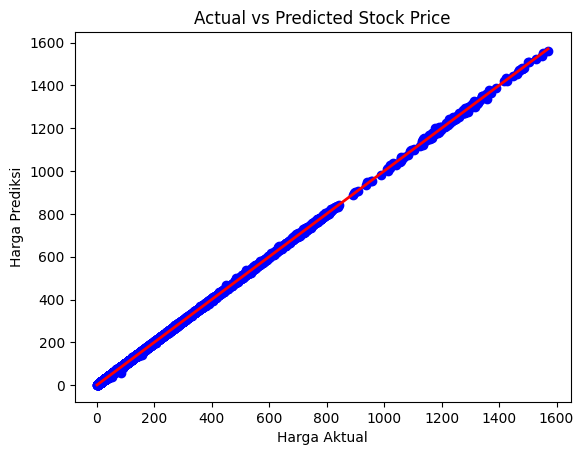

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from google.colab import files

uploaded = files.upload()

# load dataset
data = pd.read_csv("prices-split-adjusted.csv")
data.head()

# data exploration
data.info()
data.describe()

# variabel independen dan dependen
x = data[['open', 'low', 'high', 'volume']]
y = data['close']

# Split Data (90% train, 10% test)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

# Prediction
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# Visualization
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Actual vs Predicted Stock Price")
plt.show()